# Notebook 03 — Επίπεδο Ανάκτησης Πληροφορίας (Retrieval Layer)

Σε αυτό το notebook υλοποιούνται τρεις στρατηγικές ανάκτησης πάνω στο προεπεξεργασμένο corpus των tweets:

| Strategy | Περιγραφή |
|---|---|
| **BM25** | Keyword-based sparse retrieval: γρήγορη αναζήτηση με ακριβή αντιστοίχιση όρων |
| **Semantic Search** | Dense retrieval με sentence embeddings και FAISS index |
| **Hybrid Search** | Συνδυασμός BM25 και semantic scores με weighted fusion |

Για ένα ελεύθερο query, όπως `vaccines`, `Bitcoin` ή `fear anxiety terror`, κάθε στρατηγική επιστρέφει τα top-k πιο σχετικά tweets. Αυτό προσομοιώνει το retrieval στάδιο ενός συστήματος social media monitoring πάνω σε στατικό corpus.


## 1. Imports και Αρχική Ρύθμιση

Φορτώνουμε τις βιβλιοθήκες που χρειάζονται για retrieval, vector search και αποθήκευση indices. Επίσης ορίζουμε τα paths, το embedding model και τη σταθερή σειρά των 11 emotion labels.


In [1]:
import os
import pickle
import numpy as np
import pandas as pd
from pathlib import Path

# BM25
from rank_bm25 import BM25Okapi

# Semantic
from sentence_transformers import SentenceTransformer
import faiss

# Text preprocessing (reuse tokeniser)
import re

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_DIR  = Path('..').resolve()
PROC_DIR  = BASE_DIR / 'data' / 'processed'
INDEX_DIR = BASE_DIR / 'data' / 'index'
INDEX_DIR.mkdir(parents=True, exist_ok=True)

# ── Config ─────────────────────────────────────────────────────────────────────
# Sentence-transformer model (small & fast, no internet required once cached)
EMBED_MODEL = 'all-MiniLM-L6-v2'

TOP_K = 10          # default number of results to return
EMOTIONS = ['anger', 'anticipation', 'disgust', 'fear', 'joy',
            'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']

print('Imports done')

Imports done


**Αποτέλεσμα:** Φορτώθηκαν οι βασικές βιβλιοθήκες: `BM25Okapi` για keyword search, `SentenceTransformer` για semantic embeddings και `faiss` για vector indexing. Δημιουργήθηκε ο φάκελος `data/index/`, όπου θα αποθηκευτούν τα retrieval artefacts.


## 2. Φόρτωση του Processed Corpus

Φορτώνουμε το `tweets_processed.parquet` που παρήχθη στο Notebook 02. Το αρχείο περιέχει τόσο το `text_clean` για BM25/TF-IDF όσο και το `text_light` για transformer-based μοντέλα.


In [2]:
df = pd.read_parquet(PROC_DIR / 'tweets_processed.parquet')
df = df.reset_index(drop=True)   # ensure positional index = FAISS row id

print(f'Corpus size : {len(df):,} tweets')
print(f'Columns     : {list(df.columns)}')
df[['Tweet', 'text_clean', 'text_light', 'split']].head(10)

Corpus size : 10,896 tweets
Columns     : ['ID', 'Tweet', 'anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust', 'split', 'text_clean', 'text_light', 'n_tokens_clean', 'n_tokens_light']


,Tweet,text_clean,text_light,split
0,“Worry is a down payment on a problem you may ...,worry payment problem may never joyce meyer mo...,“Worry is a down payment on a problem you may ...,train
1,Whatever you decide to do make sure it makes y...,whatever decide make sure makes happy,Whatever you decide to do make sure it makes y...,train
2,@Max_Kellerman it also helps that the majorit...,also helps majority nfl coaching inept bill br...,USER it also helps that the majority of NFL co...,train
3,Accept the challenges so that you can literall...,accept challenges literally even feel exhilara...,Accept the challenges so that you can literall...,train
4,My roommate: it's okay that we can't spell bec...,roommate okay spell autocorrect terrible first...,My roommate: it's okay that we can't spell bec...,train
5,No but that's so cute. Atsu was probably shy a...,cute atsu probably shy photos cherry helped uwu,No but that's so cute. Atsu was probably shy a...,train
6,Do you think humans have the sense for recogni...,think humans sense recognizing impending doom,Do you think humans have the sense for recogni...,train
7,Rooneys fucking untouchable isn't he? Been fuc...,rooneys fucking untouchable fucking dreadful d...,Rooneys fucking untouchable isn't he? Been fuc...,train
8,it's pretty depressing when u hit pan on ur fa...,pretty depressing hit pan ur favourite highlig...,it's pretty depressing when u hit pan on ur fa...,train
9,@BossUpJaee but your pussy was weak from what ...,pussy weak heard stfu bitch got threaten pregnant,USER but your pussy was weak from what I heard...,train


**Αποτέλεσμα:** Φορτώθηκαν τα 10.896 processed tweets. Το `reset_index(drop=True)` είναι σημαντικό, γιατί εξασφαλίζει ότι ο positional index του DataFrame ταυτίζεται με τη θέση κάθε embedding στον FAISS index.


## 3. BM25 Index

Το `BM25Okapi` δουλεύει πάνω σε tokenised text. Για αυτό χρησιμοποιούμε τη στήλη `text_clean`, η οποία είναι ήδη lowercased, χωρίς stopwords και χωρίς θόρυβο από URLs/mentions.

Ο BM25 είναι κλασική sparse retrieval μέθοδος: ευνοεί documents που περιέχουν ακριβείς όρους του query, αλλά λαμβάνει υπόψη και τη σπανιότητα των όρων και το μήκος κάθε document.

Scoring formula (Okapi BM25):

```text
score(D,Q) = sum_i IDF(q_i) *
             f(q_i,D) * (k1 + 1) /
             (f(q_i,D) + k1 * (1 - b + b * |D| / avgdl))
```


In [3]:
# Tokenise the clean column (whitespace split — already clean)
corpus_tokens = [str(t).split() for t in df['text_clean']]

print('Building BM25 index...')
bm25 = BM25Okapi(corpus_tokens)

# Persist for reuse
bm25_path = INDEX_DIR / 'bm25.pkl'
with open(bm25_path, 'wb') as f:
    pickle.dump(bm25, f)

print(f'BM25 index built — {len(corpus_tokens):,} documents')
print(f'Saved to         : {bm25_path}')

Building BM25 index...
BM25 index built — 10,896 documents
Saved to         : /home/konstantinos-papadogiannis/Desktop2/SocialMediaAgent/data/index/bm25.pkl


**Αποτέλεσμα:** Ο BM25 index χτίστηκε πάνω στα 10.896 documents και αποθηκεύτηκε ως `data/index/bm25.pkl`. Χρησιμοποιείται το `text_clean`, επειδή το BM25 βασίζεται σε exact keyword matching και χρειάζεται καθαρούς, συγκρίσιμους tokens.


### 3.1 Συνάρτηση BM25 Search

Ορίζουμε βοηθητικό καθαρισμό για το query και τη συνάρτηση `bm25_search()`. Το query πρέπει να καθαρίζεται με συμβατό τρόπο προς το corpus, ώστε οι όροι του χρήστη να μπορούν να ταιριάξουν με τα tokens του `text_clean`.


In [4]:
def preprocess_query(query: str) -> list[str]:
    """Minimal cleaning that mirrors text_clean pipeline (lowercase + split)."""
    query = query.lower()
    query = re.sub(r'https?://\S+|www\.\S+', '', query)
    query = re.sub(r'[^a-z0-9\s]', ' ', query)
    return query.split()


def bm25_search(query: str, bm25_index: BM25Okapi, corpus_df: pd.DataFrame,
                top_k: int = TOP_K) -> pd.DataFrame:
    """
    Return the top-k tweets most relevant to *query* using BM25.

    Returns a DataFrame with columns:
        rank, bm25_score, Tweet, text_clean, split, <emotion labels>
    """
    tokens = preprocess_query(query)
    scores = bm25_index.get_scores(tokens)          # ndarray length N

    top_idx = np.argsort(scores)[::-1][:top_k]

    result = corpus_df.iloc[top_idx].copy()
    result['bm25_score'] = scores[top_idx]
    result.insert(0, 'rank', range(1, top_k + 1))

    return result[['rank', 'bm25_score', 'Tweet', 'text_clean', 'split'] + EMOTIONS]


print('bm25_search() ready')

bm25_search() ready


**Αποτέλεσμα:** Ορίστηκαν οι `preprocess_query()` και `bm25_search()`. Η αναζήτηση υπολογίζει BM25 scores για όλα τα tweets, τα ταξινομεί φθίνουσα και επιστρέφει τα top-k αποτελέσματα μαζί με τα emotion labels.


### 3.2 Demo — BM25

Δοκιμάζουμε το BM25 με το query `Madrid`. Εδώ περιμένουμε κυρίως tweets που περιέχουν ακριβώς τη λέξη `Madrid` ή πολύ κοντινούς όρους μετά το preprocessing.


In [5]:
DEMO_QUERY = 'Madrid'

bm25_results = bm25_search(DEMO_QUERY, bm25, df)
print(f'Query : "{DEMO_QUERY}"')
print(f'Top-{TOP_K} BM25 results:\n')# Display nicely
pd.set_option('display.max_colwidth', 90)
bm25_results[['rank', 'bm25_score', 'Tweet']].style.format({'bm25_score': '{:.4f}'})

Query : "Madrid"
Top-10 BM25 results:



,rank,bm25_score,Tweet
7886,1,8.1966,@LovinUnited That'll be Madrid throwing a huff over Morata and De Gea. Fuck them
5349,2,7.0157,@SportsTraderIT Madrid is playing awful and no modric but 90 minutes in Bernabéu stadium are so so long. Viallreal never won there
8665,3,6.4009,@UnitedStandMUFC So English clubs get over charged and other clubs like Real Madrid bully to get players on the cheap
10280,4,5.6572,Shocking business by Real Madrid and Bayern doing great business as usual. Getting a world class player in his peak on loan is brilliant.
10256,5,5.4463,@Arquipimp 😂😂😂😂\nU mean overprice English clubs\nReal Madrid see bayern as no threat then look 😂
9280,6,5.2506,"'Manchester United lose out on another Real Madrid target as James...'\n\nOnly joking, and you went and burst a blood vessel for nothing. 😉😂"
3634,7,0.0000,"It's simple I get after two shots of espresso 'Grande, decaf, 130 degrees soy americano with extra foam' #barista #nightmare"
3633,8,0.0000,I am so happy I have come across @HilltopBindery notebooks! #handmade would love to talk to you! #musthave #want #need #happy #amazing 📖🖋
3632,9,0.0000,"3 #tmobile #stores, #original #note7 #customer and zero #results... What's going on guys? #customerservice #2hour #waittime"
3631,10,0.0000,Please stop your merriment. It is very annoying


**Αποτέλεσμα:** Για το query `Madrid`, το BM25 επέστρεψε tweets με ισχυρό exact keyword overlap. Τα BM25 scores είναι unbounded, δηλαδή δεν έχουν σταθερό άνω όριο· χρησιμοποιούνται κυρίως για σχετική κατάταξη μέσα στο ίδιο query.


## 4. Semantic Index (Sentence-Transformers + FAISS)

Για semantic search κωδικοποιούμε κάθε tweet με το `all-MiniLM-L6-v2`, ένα sentence-transformer μοντέλο που παράγει embeddings 384 διαστάσεων.

Χρησιμοποιούμε τη στήλη `text_light`, επειδή τα transformer-based μοντέλα μπορούν να αξιοποιήσουν hashtags, emojis και tweet-specific στοιχεία. Τα embeddings γίνονται L2-normalized, ώστε το inner product στον FAISS index να ισοδυναμεί με cosine similarity.

> Στην πρώτη εκτέλεση το μοντέλο κατεβαίνει από το HuggingFace Hub. Στις επόμενες εκτελέσεις φορτώνεται από local cache.


In [6]:
print(f'Loading sentence-transformer: {EMBED_MODEL} ...')
embedder = SentenceTransformer(EMBED_MODEL)

embed_cache = INDEX_DIR / 'embeddings.npy'

if embed_cache.exists():
    print('Loading cached embeddings...')
    embeddings = np.load(embed_cache)
else:
    print(f'Encoding {len(df):,} tweets (this may take a few minutes)...')
    # Use text_light: preserves hashtags/emojis → better semantic signal
    embeddings = embedder.encode(
        df['text_light'].tolist(),
        batch_size=256,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True   # L2-normalise so inner product = cosine
    )
    np.save(embed_cache, embeddings)
    print(f'Saved embeddings to {embed_cache}')

print(f'Embeddings shape: {embeddings.shape}')   # (N, 384)

Loading sentence-transformer: all-MiniLM-L6-v2 ...
Loading cached embeddings...
Embeddings shape: (10896, 384)


**Αποτέλεσμα:** Φορτώθηκε το `all-MiniLM-L6-v2` και δημιουργήθηκαν ή φορτώθηκαν τα embeddings με shape `10.896 × 384`. Η χρήση `normalize_embeddings=True` επιτρέπει στο FAISS `IndexFlatIP` να λειτουργεί ως cosine similarity search.


In [7]:
# Build FAISS index
dim = embeddings.shape[1]
faiss_index = faiss.IndexFlatIP(dim)   # inner product (= cosine after normalisation)
faiss_index.add(embeddings)

# Persist
faiss_path = INDEX_DIR / 'faiss.index'
faiss.write_index(faiss_index, str(faiss_path))

print(f'FAISS index built  : {faiss_index.ntotal:,} vectors, dim={dim}')
print(f'Saved to           : {faiss_path}')

FAISS index built  : 10,896 vectors, dim=384
Saved to           : /home/konstantinos-papadogiannis/Desktop2/SocialMediaAgent/data/index/faiss.index


**Αποτέλεσμα:** Χτίστηκε ο FAISS index τύπου `IndexFlatIP` με 10.896 vectors των 384 διαστάσεων και αποθηκεύτηκε στο `data/index/faiss.index`. Το index χρησιμοποιείται για γρήγορη εύρεση των nearest neighbours του query embedding.


### 4.1 Συνάρτηση Semantic Search

Η `semantic_search()` κωδικοποιεί το query σε embedding, εκτελεί αναζήτηση στον FAISS index και επιστρέφει τα top-k πιο κοντινά tweets στο embedding space.

Σε αντίθεση με το BM25, εδώ μπορούν να βρεθούν σχετικά tweets ακόμα και όταν δεν περιέχουν ακριβώς τις ίδιες λέξεις με το query.


In [8]:
def semantic_search(query: str, embedder: SentenceTransformer,
                    faiss_index, corpus_df: pd.DataFrame,
                    top_k: int = TOP_K) -> pd.DataFrame:
    """
    Return the top-k tweets most semantically similar to *query*.

    Returns a DataFrame with:
        rank, sem_score, Tweet, text_light, split, <emotion labels>
    """
    q_emb = embedder.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True
    )                                        # shape (1, 384)

    scores, idx = faiss_index.search(q_emb, top_k)   # each shape (1, top_k)
    scores = scores[0]
    idx    = idx[0]

    result = corpus_df.iloc[idx].copy()
    result['sem_score'] = scores
    result.insert(0, 'rank', range(1, top_k + 1))

    return result[['rank', 'sem_score', 'Tweet', 'text_light', 'split'] + EMOTIONS]


print('semantic_search() ready')

semantic_search() ready


**Αποτέλεσμα:** Ορίστηκε η `semantic_search()`. Η συνάρτηση επιστρέφει cosine similarities στο εύρος περίπου `[0, 1]`, μαζί με τα αντίστοιχα tweets και emotion labels.


### 4.2 Demo — Semantic Search

Δοκιμάζουμε το semantic search στο ίδιο query `Madrid`, ώστε να συγκρίνουμε τη συμπεριφορά του με το BM25. Η semantic προσέγγιση μπορεί να ανασύρει tweets που είναι νοηματικά κοντά, ακόμη κι αν δεν υπάρχει ακριβές token match.


In [9]:
sem_results = semantic_search(DEMO_QUERY, embedder, faiss_index, df)
print(f'Query : "{DEMO_QUERY}"')
print(f'Top-{TOP_K} Semantic results:\n')
sem_results[['rank', 'sem_score', 'Tweet']].style.format({'sem_score': '{:.4f}'})

Query : "Madrid"
Top-10 Semantic results:



,rank,sem_score,Tweet
5349,1,0.5509,@SportsTraderIT Madrid is playing awful and no modric but 90 minutes in Bernabéu stadium are so so long. Viallreal never won there
7886,2,0.5137,@LovinUnited That'll be Madrid throwing a huff over Morata and De Gea. Fuck them
2265,3,0.4819,Ramos with his ground shaking headers..😏
10280,4,0.4789,Shocking business by Real Madrid and Bayern doing great business as usual. Getting a world class player in his peak on loan is brilliant.
10256,5,0.4615,@Arquipimp 😂😂😂😂\nU mean overprice English clubs\nReal Madrid see bayern as no threat then look 😂
9280,6,0.4243,"'Manchester United lose out on another Real Madrid target as James...'\n\nOnly joking, and you went and burst a blood vessel for nothing. 😉😂"
5357,7,0.4218,Losing to Villa...'@M0tivati0nQuote: Most of the things people worry about are things that won't even matter to them a few months from now.'
2346,8,0.4217,RM will win the game at the last minutes and Madridistas will say Cules stayed this long watching RM win at the end. Disgusting fanbase
3112,9,0.4188,the teams that face Barca and Bayern after a defeat are the ones who face the wrath
8665,10,0.4140,@UnitedStandMUFC So English clubs get over charged and other clubs like Real Madrid bully to get players on the cheap


**Αποτέλεσμα:** Για το query `Madrid`, το semantic search επέστρεψε tweets που σχετίζονται νοηματικά με την έννοια του query, όχι απαραίτητα μόνο tweets με ακριβή εμφάνιση της λέξης. Αυτό δείχνει τη συμπληρωματικότητα sparse και dense retrieval.


## 5. Hybrid Search (BM25 + Semantic)

Το hybrid retrieval συνδυάζει τα δύο score vectors με min-max normalization και weighted sum:

```text
hybrid_score = alpha * BM25_norm + (1 - alpha) * semantic_norm
```

Το `alpha` ελέγχει πόσο βάρος δίνεται στο BM25. Όταν `alpha = 0`, η αναζήτηση είναι καθαρά semantic· όταν `alpha = 1`, είναι καθαρά BM25. Στο notebook χρησιμοποιείται default `alpha = 0.3`, δηλαδή δίνεται μεγαλύτερο βάρος στο semantic signal χωρίς να χάνεται το keyword signal.


In [10]:
def minmax_norm(arr: np.ndarray) -> np.ndarray:
    lo, hi = arr.min(), arr.max()
    if hi == lo:
        return np.zeros_like(arr)
    return (arr - lo) / (hi - lo)


def hybrid_search(query: str,
                  bm25_index: BM25Okapi,
                  embedder: SentenceTransformer,
                  faiss_index,
                  corpus_df: pd.DataFrame,
                  top_k: int = TOP_K,
                  alpha: float = 0.3) -> pd.DataFrame:
    """
    Hybrid retrieval: alpha * BM25 + (1-alpha) * Semantic.

    Parameters
    ----------
    alpha : float
        Weight of BM25 component (0 = pure semantic, 1 = pure BM25).

    Returns a DataFrame with:
        rank, hybrid_score, bm25_norm, sem_norm, Tweet, split, <emotions>
    """
    # ── BM25 scores (all documents)
    tokens     = preprocess_query(query)
    bm25_raw   = bm25_index.get_scores(tokens)          # shape (N,)
    bm25_norm  = minmax_norm(bm25_raw)

    # ── Semantic scores (all documents via inner product)
    q_emb = embedder.encode(
        [query], normalize_embeddings=True, convert_to_numpy=True)
    # Search whole index (ntotal)
    sem_raw, sem_idx = faiss_index.search(q_emb, faiss_index.ntotal)
    sem_raw  = sem_raw[0]   # cosine similarities, possibly unsorted after re-indexing
    sem_idx  = sem_idx[0]

    # Reorder semantic scores into corpus order
    sem_aligned = np.empty(len(corpus_df), dtype=np.float32)
    sem_aligned[sem_idx] = sem_raw
    sem_norm = minmax_norm(sem_aligned)

    # ── Fuse
    hybrid = alpha * bm25_norm + (1 - alpha) * sem_norm

    top_idx = np.argsort(hybrid)[::-1][:top_k]

    result = corpus_df.iloc[top_idx].copy()
    result['hybrid_score'] = hybrid[top_idx]
    result['bm25_norm']    = bm25_norm[top_idx]
    result['sem_norm']     = sem_norm[top_idx]
    result.insert(0, 'rank', range(1, top_k + 1))

    return result[['rank', 'hybrid_score', 'bm25_norm', 'sem_norm',
                   'Tweet', 'split'] + EMOTIONS]


print('hybrid_search() ready')

hybrid_search() ready


**Αποτέλεσμα:** Ορίστηκε η `hybrid_search()`. Η συνάρτηση υπολογίζει BM25 και semantic scores για όλο το corpus, τα κανονικοποιεί στο `[0, 1]`, τα συνδυάζει με το `alpha` και επιστρέφει τα top-k tweets με βάση το fused score.


### 5.1 Demo — Hybrid Search

Εφαρμόζουμε το hybrid search στο query `Madrid`. Στον πίνακα εμφανίζονται το τελικό `hybrid_score`, αλλά και οι επιμέρους συνεισφορές `bm25_norm` και `sem_norm`.


In [11]:
hyb_results = hybrid_search(DEMO_QUERY, bm25, embedder, faiss_index, df)
print(f'Query : "{DEMO_QUERY}"')
print(f'Top-{TOP_K} Hybrid results (alpha=0.3):\n')
hyb_results[['rank', 'hybrid_score', 'bm25_norm', 'sem_norm', 'Tweet']]\
    .style.format({'hybrid_score': '{:.4f}', 'bm25_norm': '{:.4f}', 'sem_norm': '{:.4f}'})

Query : "Madrid"
Top-10 Hybrid results (alpha=0.3):



,rank,hybrid_score,bm25_norm,sem_norm,Tweet
7886,1,0.9646,1.0000,0.9494,@LovinUnited That'll be Madrid throwing a huff over Morata and De Gea. Fuck them
5349,2,0.9568,0.8559,1.0000,@SportsTraderIT Madrid is playing awful and no modric but 90 minutes in Bernabéu stadium are so so long. Viallreal never won there
10280,3,0.8384,0.6902,0.9019,Shocking business by Real Madrid and Bayern doing great business as usual. Getting a world class player in his peak on loan is brilliant.
10256,4,0.8140,0.6645,0.8781,@Arquipimp 😂😂😂😂\nU mean overprice English clubs\nReal Madrid see bayern as no threat then look 😂
8665,5,0.8037,0.7809,0.8134,@UnitedStandMUFC So English clubs get over charged and other clubs like Real Madrid bully to get players on the cheap
9280,6,0.7714,0.6406,0.8274,"'Manchester United lose out on another Real Madrid target as James...'\n\nOnly joking, and you went and burst a blood vessel for nothing. 😉😂"
2265,7,0.6341,0.0000,0.9059,Ramos with his ground shaking headers..😏
5357,8,0.5768,0.0000,0.8240,Losing to Villa...'@M0tivati0nQuote: Most of the things people worry about are things that won't even matter to them a few months from now.'
2346,9,0.5767,0.0000,0.8239,RM will win the game at the last minutes and Madridistas will say Cules stayed this long watching RM win at the end. Disgusting fanbase
3112,10,0.5740,0.0000,0.8200,the teams that face Barca and Bayern after a defeat are the ones who face the wrath


**Αποτέλεσμα:** Το hybrid search συνδύασε exact matches από το BM25 και νοηματικά σχετικά αποτελέσματα από το semantic search. Τα hybrid scores είναι συγκρίσιμα στο `[0, 1]` λόγω normalization.


## 6. Multi-Query Demo

Δοκιμάζουμε το hybrid retrieval σε διαφορετικά θεματικά queries. Αυτό δείχνει αν το retrieval layer μπορεί να ανταποκριθεί σε ποικίλες αναζητήσεις, όπως υγεία, οικονομία, περιβάλλον και συναισθηματικά φορτισμένα θέματα.


In [12]:
from IPython.display import display

demo_queries = [
    'vaccines health pandemic',
    'Bitcoin crypto',
    'climate change environment',
    'happy birthday love',
    'anxiety depression mental health',
]

rows = []
for q in demo_queries:
    res = hybrid_search(q, bm25, embedder, faiss_index, df, top_k=3)
    for _, row in res.iterrows():
        emotions_on = ', '.join([e for e in EMOTIONS if row[e] == 1]) or '—'
        rows.append({
            'Query'        : q,
            'Rank'         : int(row['rank']),     # ← row['rank'], ΟΧΙ row.rank
            'Score'        : round(row['hybrid_score'], 3),
            'Emotions'     : emotions_on,
            'Tweet'        : row['Tweet'][:120],
        })

demo_df = pd.DataFrame(rows)

(demo_df.style
 .set_caption('🔍 Hybrid Search — Multi-Query Demo')
 .format({'Score': '{:.3f}'})
 .background_gradient(subset=['Score'], cmap='RdYlGn', vmin=0.6, vmax=1.0)
 .set_properties(**{'text-align': 'left', 'white-space': 'normal'})
 .set_table_styles([
     {'selector': 'caption',
      'props': [('font-size','15px'),('font-weight','bold'),('padding','8px 0'),('text-align','left')]},
     {'selector': 'th',
      'props': [('background-color','black'),('color','white'),
                ('font-weight','bold'),('padding','8px 14px')]},
     {'selector': 'td',
      'props': [('padding','6px 14px'),('vertical-align','top')]},
     {'selector': 'tr:nth-child(odd)',
      'props': [('background-color','dark-grey')]},
 ])
)


,Query,Rank,Score,Emotions,Tweet
0,vaccines health pandemic,1,0.720,sadness,in health we did a think about depression and now i feel like i have it
1,vaccines health pandemic,2,0.705,"anger, disgust, fear, pessimism",We have a GLOBAL problem: Illicit trade in #tobacco products presents a serious #threat to public #health. #UNTobaccocon
2,vaccines health pandemic,3,0.700,—,He who is affected by an insult is infected by it.
3,Bitcoin crypto,1,1.000,disgust,@MarkTOByrne I offered @WholeFoods @amazon @CheapAir gold or silver but they said Nah... #bitcoin
4,Bitcoin crypto,2,0.953,"anger, disgust, optimism",complainin bitcoin has dropped. The altcoin bubble has burst. Bitcoin cud go to $1800 mid/end July but will rise above p
5,Bitcoin crypto,3,0.894,"anger, disgust",@MarkTOByrne I offered @WholeFoods @amazon @CheapAir gold or silver but they said Nah... #bitcoin #snap
6,climate change environment,1,1.000,"anger, disgust","@CNN thanks Hollywood, (Depp). all these climate change fanatics using private jets and gas guzzling cars are to blame f"
7,climate change environment,2,0.709,"joy, optimism, pessimism",The pessimist complains about the wind; the optimist expects it to change; the realist adjusts the sails.
8,climate change environment,3,0.671,"fear, sadness",I keep getting so worried about the amount of plastic that gets thrown away atm as if I didn't panic enough about the en
9,happy birthday love,1,0.979,joy,HAPPY BIRTHDAY! :D


**Αποτέλεσμα:** Το hybrid search λειτουργεί σε διαφορετικά queries. Για παράδειγμα, το `anxiety depression mental health` επιστρέφει tweets με `fear`, `sadness` και `pessimism`, ενώ το `happy birthday love` επιστρέφει κυρίως tweets με `joy`, `love` και `optimism`.


## 7. Σύγκριση Στρατηγικών Side-by-Side

Συγκρίνουμε BM25, Semantic και Hybrid για το ίδιο query. Η σύγκριση βοηθά να φανεί πρακτικά τι κερδίζει και τι χάνει κάθε στρατηγική.


In [13]:
from IPython.display import display, HTML

COMPARE_QUERY = 'fear anxiety terror'
K = 5

pd.set_option('display.max_colwidth', 110)

bm25_r = bm25_search(COMPARE_QUERY, bm25,    df, top_k=K)
sem_r  = semantic_search(COMPARE_QUERY, embedder, faiss_index, df, top_k=K)
hyb_r  = hybrid_search(COMPARE_QUERY,  bm25, embedder, faiss_index, df, top_k=K)

print(f'Query: "{COMPARE_QUERY}"\n')

# ── helper για στυλ πίνακα ─────────────────────────────────────────────────────
def show_table(df_in, score_col, title, cmap='Blues'):
    sub = df_in[['rank', score_col, 'Tweet']].copy()
    sub = sub.rename(columns={score_col: 'score'})
    sub['Tweet'] = sub['Tweet'].str[:110]
    styled = (
        sub.style
        .set_caption(title)
        .format({'score': '{:.4f}'})
        .background_gradient(subset=['score'], cmap=cmap)
        .set_properties(**{'text-align': 'left', 'white-space': 'normal', 'max-width': '700px'})
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size','14px'),('font-weight','bold'),
                       ('text-align','left'),('padding','8px 0 4px 0')]},
            {'selector': 'th', 'props': [('background-color','dark-grey'),
                                          ('padding','6px 10px')]},
            {'selector': 'td', 'props': [('padding','5px 10px'),
                                          ('vertical-align','top')]},
        ])
        .hide(axis='index')
    )
    display(styled)
    display(HTML('<br>'))

show_table(bm25_r, 'bm25_score', 'BM25  (raw score — unbounded, higher = more keyword overlap)', cmap='Oranges')
show_table(sem_r,  'sem_score',  'Semantic  (cosine similarity ∈ [0, 1])', cmap='Blues')
show_table(hyb_r,  'hybrid_score','Hybrid  (0.3 × BM25_norm + 0.7 × Semantic_norm, ∈ [0, 1])', cmap='Greens')


Query: "fear anxiety terror"



rank,score,Tweet
1,7.7068,@olark @mashable Thanks @olark for being #awesome As someone who suffers from #Anxiety and migraines I always
2,7.5024,@NaziaMemon01 yeah a terror packed terror supported speech..
3,7.3691,"I have to be completely honest, this era triggered my anxiety quite a lot... the things Hayley talk about is w"
4,7.3318,I'm so over having anxiety
5,7.3095,"----- #phobia = irrational fear of or aversion to something. Synonyms: dread, horror, terror, dislike, distast"


rank,score,Tweet
1,0.6481,"----- #phobia = irrational fear of or aversion to something. Synonyms: dread, horror, terror, dislike, distast"
2,0.6169,Why do I have such bad anxiety it's annoying
3,0.5890,My anxiety is playing around HELP!!!!!
4,0.5805,"Avoiding #fears only makes them scarier. Whatever your #fear, if you face it, it should start to fade. #courag"
5,0.5678,"Don't be afraid of your fears. Their purpose is not to frighten you, but enlighten you and lead you into a bet"


rank,score,Tweet
1,0.9845,"----- #phobia = irrational fear of or aversion to something. Synonyms: dread, horror, terror, dislike, distast"
2,0.9173,Why do I have such bad anxiety it's annoying
3,0.8970,I'm so over having anxiety
4,0.8838,anxiety pays off
5,0.8830,#terror test ................


**Αποτέλεσμα:** Για το query `fear anxiety terror`, το BM25 δίνει υψηλή ακρίβεια όταν υπάρχουν ακριβείς λέξεις, το semantic search βρίσκει νοηματικά κοντινά tweets όπως `panic`, `nightmare` ή `terrified`, και το hybrid συνδυάζει τα δύο σήματα.


## 8. Αξιολόγηση Retrieval — Precision@k, Recall@k, nDCG@k

Για να αξιολογήσουμε πόσο καλά βρίσκει κάθε στρατηγική τα σχετικά tweets, χρησιμοποιούμε τρεις κλασικές Information Retrieval metrics:

| Metric | Τι μετράει |
|---|---|
| **Precision@k** | Από τα k αποτελέσματα που επέστρεψε το σύστημα, πόσα είναι σχετικά |
| **Recall@k** | Από όλα τα σχετικά tweets του corpus, πόσα βρέθηκαν μέσα στα top-k |
| **nDCG@k** | Αν τα σχετικά αποτελέσματα εμφανίζονται ψηλά στο ranking |

> **Proxy relevance:** Επειδή δεν υπάρχουν human relevance annotations για τα queries, θεωρούμε σχετικό ένα tweet όταν το `text_clean` περιέχει τουλάχιστον ένα token του query. Αυτό είναι πρακτικό proxy για αξιολόγηση, αλλά όχι τέλειο ground truth.


In [14]:
import math

# ── Ορισμός μετρικών ──────────────────────────────────────────────────────────

def get_relevant_set(query: str, corpus_df: pd.DataFrame) -> set:
    """
    Proxy relevance: ένα tweet θεωρείται relevant αν στο text_clean
    περιέχει τουλάχιστον 1 token du query.
    """
    tokens = preprocess_query(query)
    mask = corpus_df['text_clean'].apply(
        lambda t: any(tok in str(t).split() for tok in tokens)
    )
    return set(corpus_df.index[mask])


def precision_at_k(retrieved_indices, relevant_set, k):
    """
    Precision@k = |relevant ∩ retrieved[:k]| / k
    """
    top_k = retrieved_indices[:k]
    relevant_found = sum(1 for idx in top_k if idx in relevant_set)
    return relevant_found / k


def recall_at_k(retrieved_indices, relevant_set, k):
    """
    Recall@k = |relevant ∩ retrieved[:k]| / |relevant|
    """
    if len(relevant_set) == 0:
        return 0.0
    top_k = retrieved_indices[:k]
    relevant_found = sum(1 for idx in top_k if idx in relevant_set)
    return relevant_found / len(relevant_set)


def dcg_at_k(retrieved_indices, relevant_set, k):
    """
    DCG@k = Σ_{i=1}^{k}  rel_i / log2(i+1)
    """
    score = 0.0
    for i, idx in enumerate(retrieved_indices[:k]):
        rel = 1.0 if idx in relevant_set else 0.0
        score += rel / math.log2(i + 2)      # i+2 γιατί i ξεκινά από 0
    return score


def ndcg_at_k(retrieved_indices, relevant_set, k):
    """
    nDCG@k = DCG@k / IDCG@k
    """
    dcg = dcg_at_k(retrieved_indices, relevant_set, k)
    # Ιδανικό ranking: όλα τα relevant πρώτα
    ideal_k = min(k, len(relevant_set))
    idcg = sum(1.0 / math.log2(i + 2) for i in range(ideal_k))
    if idcg == 0:
        return 0.0
    return dcg / idcg


# ── Queries για αξιολόγηση ────────────────────────────────────────────────────
eval_queries = [
    'fear anxiety terror',
    'happy birthday love',
    'climate change environment',
    'Bitcoin crypto',
    'vaccines health pandemic',
    'anger hate violence',
    'depression sadness lonely',
]

K_VALUES = [5, 10, 20]

# ── Αξιολόγηση κάθε strategy ──────────────────────────────────────────────────
rows = []
for query in eval_queries:
    relevant = get_relevant_set(query, df)

    # BM25
    bm25_r = bm25_search(query, bm25, df, top_k=max(K_VALUES))
    bm25_idx = bm25_r.index.tolist()

    # Semantic
    sem_r = semantic_search(query, embedder, faiss_index, df, top_k=max(K_VALUES))
    sem_idx = sem_r.index.tolist()

    # Hybrid
    hyb_r = hybrid_search(query, bm25, embedder, faiss_index, df, top_k=max(K_VALUES))
    hyb_idx = hyb_r.index.tolist()

    for k in K_VALUES:
        for strategy_name, idx_list in [('BM25', bm25_idx),
                                         ('Semantic', sem_idx),
                                         ('Hybrid', hyb_idx)]:
            rows.append({
                'Query': query,
                'Strategy': strategy_name,
                'k': k,
                'Precision@k': round(precision_at_k(idx_list, relevant, k), 4),
                'Recall@k':    round(recall_at_k(idx_list, relevant, k),    4),
                'nDCG@k':      round(ndcg_at_k(idx_list, relevant, k),      4),
                '|Relevant|':  len(relevant),
            })

metrics_df = pd.DataFrame(rows)

# ── Εμφάνιση: μέσος όρος ανά Strategy × k ────────────────────────────────────
avg_metrics = (
    metrics_df.groupby(['Strategy', 'k'])[['Precision@k', 'Recall@k', 'nDCG@k']]
    .mean()
    .round(4)
)

print('═' * 70)
print('  Retrieval Metrics — Μέσος όρος σε', len(eval_queries), 'queries')
print('═' * 70)
display(
    avg_metrics.style
    .format('{:.4f}')
    .background_gradient(subset=['Precision@k'], cmap='Greens')
    .background_gradient(subset=['Recall@k'],    cmap='Blues')
    .background_gradient(subset=['nDCG@k'],      cmap='Oranges')
    .set_caption('📊 Average Retrieval Metrics per Strategy')
)

# ── Detailed per-query table ──────────────────────────────────────────────────
print()
print('═' * 70)
print('  Per-query breakdown (k = 10)')
print('═' * 70)

detail = metrics_df[metrics_df['k'] == 10].copy()
display(
    detail[['Query', 'Strategy', 'Precision@k', 'Recall@k', 'nDCG@k', '|Relevant|']]
    .style
    .format({
        'Precision@k': '{:.4f}',
        'Recall@k': '{:.4f}',
        'nDCG@k': '{:.4f}',
    })
    .background_gradient(subset=['Precision@k'], cmap='Greens')
    .background_gradient(subset=['nDCG@k'],      cmap='Oranges')
    .set_caption('📊 Detailed Retrieval Metrics (k=10)')
    .hide(axis='index')
)


══════════════════════════════════════════════════════════════════════
  Retrieval Metrics — Μέσος όρος σε 7 queries
══════════════════════════════════════════════════════════════════════



══════════════════════════════════════════════════════════════════════
  Per-query breakdown (k = 10)
══════════════════════════════════════════════════════════════════════


Query,Strategy,Precision@k,Recall@k,nDCG@k,|Relevant|
fear anxiety terror,BM25,1.0000,0.0254,1.0000,393
fear anxiety terror,Semantic,0.9000,0.0229,0.9266,393
fear anxiety terror,Hybrid,1.0000,0.0254,1.0000,393
happy birthday love,BM25,1.0000,0.0132,1.0000,760
happy birthday love,Semantic,1.0000,0.0132,1.0000,760
happy birthday love,Hybrid,1.0000,0.0132,1.0000,760
climate change environment,BM25,1.0000,0.1562,1.0000,64
climate change environment,Semantic,0.1000,0.0156,0.2201,64
climate change environment,Hybrid,0.6000,0.0938,0.6840,64
Bitcoin crypto,BM25,0.3000,1.0000,1.0000,3


**Αποτέλεσμα:** Αξιολογήθηκαν οι τρεις στρατηγικές σε 7 queries και για `k ∈ {5, 10, 20}`. Επειδή η proxy relevance είναι keyword-based, το BM25 έχει φυσικό πλεονέκτημα στο Precision@k. Το Hybrid όμως προσφέρει πιο ισορροπημένο ranking, αξιοποιώντας και keyword precision και semantic recall.


## 9. Κατανομή Συναισθημάτων στα Retrieved Results

Για ένα demo query εξετάζουμε ποια emotion labels εμφανίζονται συχνότερα στα top retrieved tweets. Αυτό συνδέει το retrieval layer με το emotion analysis που χρησιμοποιείται στα επόμενα notebooks και στο dashboard.


/tmp/ipykernel_28924/2107735744.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emo_counts.index, y=emo_counts.values, palette='coolwarm', ax=ax)


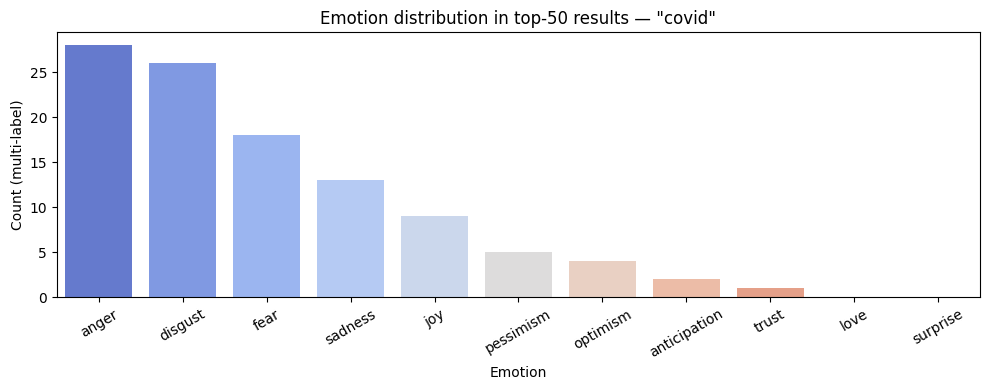

Emotion distribution plot saved.


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

QUERY_FOR_EMO = 'covid'
RES_K = 50

hyb_50 = hybrid_search(QUERY_FOR_EMO, bm25, embedder, faiss_index, df, top_k=RES_K)

emo_counts = hyb_50[EMOTIONS].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=emo_counts.index, y=emo_counts.values, palette='coolwarm', ax=ax)
ax.set_title(f'Emotion distribution in top-{RES_K} results — "{QUERY_FOR_EMO}"')
ax.set_xlabel('Emotion')
ax.set_ylabel('Count (multi-label)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(INDEX_DIR / 'emotion_dist_retrieved.png', dpi=120)
plt.show()
print('Emotion distribution plot saved.')

**Αποτέλεσμα:** Για το query `covid`, τα top-50 retrieved tweets έχουν κυρίαρχα emotions `fear` και `sadness`, κάτι αναμενόμενο για περιεχόμενο σχετικό με πανδημία. Το διάγραμμα αποθηκεύτηκε στο `data/index/emotion_dist_retrieved.png`.

![Emotion Distribution in Top-50 Retrieved Tweets for "covid"](../data/index/emotion_dist_retrieved.png)


## 10. Αποθήκευση Retrieval Artefacts

Στο τέλος αποθηκεύουμε τα βασικά artefacts του retrieval layer, ώστε να μπορούν να χρησιμοποιηθούν από τα επόμενα notebooks και από το web app χωρίς να ξαναχτιστούν από την αρχή.


In [16]:
import pickle

# ── Save BM25 index ──────────────────────────────────────────────────────
with open(INDEX_DIR / 'bm25.pkl', 'wb') as f:
    pickle.dump(bm25, f)

# ── Save FAISS index ─────────────────────────────────────────────────────
faiss.write_index(faiss_index, str(INDEX_DIR / 'faiss.index'))

# ── Save embeddings ──────────────────────────────────────────────────────
np.save(INDEX_DIR / 'embeddings.npy', embeddings)

print(f'Saved BM25 index    → {INDEX_DIR}/bm25.pkl')
print(f'Saved FAISS index   → {INDEX_DIR}/faiss.index')
print(f'Saved embeddings    → {INDEX_DIR}/embeddings.npy')

# ── List artefacts ───────────────────────────────────────────────────────
print(f'\nArtefacts in {INDEX_DIR}:')
for p in sorted(INDEX_DIR.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f'  {p.name:45s} {size_kb:>8.1f} KB')


Saved BM25 index    → /home/konstantinos-papadogiannis/Desktop2/SocialMediaAgent/data/index/bm25.pkl
Saved FAISS index   → /home/konstantinos-papadogiannis/Desktop2/SocialMediaAgent/data/index/faiss.index
Saved embeddings    → /home/konstantinos-papadogiannis/Desktop2/SocialMediaAgent/data/index/embeddings.npy

Artefacts in /home/konstantinos-papadogiannis/Desktop2/SocialMediaAgent/data/index:
  bm25.pkl                                        1319.1 KB
  embeddings.npy                                 16344.1 KB
  emotion_dist_retrieved.png                        40.4 KB
  faiss.index                                    16344.0 KB


**Αποτέλεσμα:** Αποθηκεύτηκαν τα τρία κύρια artefacts στο `data/index/`:

- `bm25.pkl` — serialized BM25 object με τα sparse retrieval statistics
- `embeddings.npy` — numpy array με shape `10.896 × 384`
- `faiss.index` — FAISS index για nearest-neighbour semantic search

Μαζί με το `data/processed/tweets_processed.parquet`, αυτά είναι τα απαραίτητα αρχεία για να λειτουργήσει το retrieval κομμάτι του web app.
